In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-01.csv')
df.head(5)


,V1,V2,V3,V4,V5
0,54.967142,118.523551,191.980663,231.134443,216.241086
1,48.617357,138.188333,177.739011,177.952571,242.774067
2,56.476885,72.028649,151.788911,167.272045,210.379004
3,65.230299,111.259385,130.591897,199.865022,234.601923
4,47.658466,86.987149,170.946699,193.192615,155.319267


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled_data)

In [ ]:
# Function to compute silhouette scores for a range of k
def compute_silhouette_scores(model_type, data, k_range=range(2, 8)):
    scores = {}
    if model_type == 'KMeans':
        for k in k_range:
            model = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = model.fit_predict(data)
            scores[k] = silhouette_score(data, labels)
    elif model_type == 'GMM':
        for k in k_range:
            model = GaussianMixture(n_components=k, random_state=42)
            labels = model.fit_predict(data)
            scores[k] = silhouette_score(data, labels)
    elif model_type == 'HC':
        Z = linkage(data, method='ward')
        for k in k_range:
            labels = fcluster(Z, k, criterion='maxclust')
            scores[k] = silhouette_score(data, labels)
    return scores

# Additional imports needed for clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster
import warnings
warnings.filterwarnings('ignore')

# Compute scores for each model
k_range = range(2, 8)
kmeans_scores = compute_silhouette_scores('KMeans', pca_data, k_range)
gmm_scores = compute_silhouette_scores('GMM', pca_data, k_range)
hc_scores = compute_silhouette_scores('HC', pca_data, k_range)

# Find best model (max score across all k)
all_scores = {**kmeans_scores, **gmm_scores, **hc_scores}
best_overall_score = max(all_scores.values())
best_model = max(['KMeans', 'GMM', 'HC'], key=lambda m: max([kmeans_scores.get(k, 0) if m=='KMeans' else gmm_scores.get(k, 0) if m=='GMM' else hc_scores.get(k, 0) for k in k_range]))

# Find optimal k for best model
if best_model == 'KMeans':
    optimal_k = max(kmeans_scores, key=kmeans_scores.get)
elif best_model == 'GMM':
    optimal_k = max(gmm_scores, key=gmm_scores.get)
else:  # HC
    optimal_k = max(hc_scores, key=hc_scores.get)

print(f"\nSilhouette Scores:")
print("KMeans:", {k: f"{v:.3f}" for k, v in kmeans_scores.items()})
print("GMM:", {k: f"{v:.3f}" for k, v in gmm_scores.items()})
print("HC:", {k: f"{v:.3f}" for k, v in hc_scores.items()})

print(f"\nBest Model: {best_model} (max silhouette: {max([max(kmeans_scores.values()), max(gmm_scores.values()), max(hc_scores.values())]):.3f})")
print(f"Optimal k for {best_model}: {optimal_k} (silhouette: {locals()[best_model.lower() + '_scores'][optimal_k]:.3f})")


Silhouette Scores:
KMeans: {2: '0.311', 3: '0.315', 4: '0.317', 5: '0.332', 6: '0.358', 7: '0.340'}
GMM: {2: '0.310', 3: '0.317', 4: '0.316', 5: '0.302', 6: '0.352', 7: '0.333'}
HC: {2: '0.277', 3: '0.273', 4: '0.281', 5: '0.295', 6: '0.301', 7: '0.271'}

Best Model: KMeans (max silhouette: 0.358)
Optimal k for KMeans: 6 (silhouette: 0.358)


In [ ]:
scores = {"KMeans": {}, "GMM": {}, "HC": {}}

for k in range(2, 8):
    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200)
    kmeans_labels = kmeans.fit_predict(pca_data)
    scores["KMeans"][k] = round(silhouette_score(pca_data, kmeans_labels), 3)

    # GMM
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=2, max_iter=200)
    gmm_labels = gmm.fit_predict(pca_data)
    scores["GMM"][k] = round(silhouette_score(pca_data, gmm_labels), 3)

    # Hierarchical Clustering
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    hc_labels = hc.fit_predict(pca_data)
    scores["HC"][k] = round(silhouette_score(pca_data, hc_labels), 3)

# Find best model & cluster count
best_model = None
best_k = None
best_score = -1

for model, model_scores in scores.items():
    for k, s in model_scores.items():
        if s > best_score:
            best_score = s
            best_model = model
            best_k = k

# Print results
print("Silhouette Scores:")
for model, model_scores in scores.items():
    print(f"{model}: {model_scores}")

print(f"\nBest Model: {best_model} (max silhouette: {best_score})")
print(f"Optimal k for {best_model}: {best_k} (silhouette: {best_score})")

Silhouette Scores:
KMeans: {2: np.float64(0.311), 3: np.float64(0.315), 4: np.float64(0.317), 5: np.float64(0.318), 6: np.float64(0.358), 7: np.float64(0.34)}
GMM: {2: np.float64(0.31), 3: np.float64(0.291), 4: np.float64(0.316), 5: np.float64(0.302), 6: np.float64(0.35), 7: np.float64(0.333)}
HC: {2: np.float64(0.277), 3: np.float64(0.273), 4: np.float64(0.281), 5: np.float64(0.295), 6: np.float64(0.301), 7: np.float64(0.271)}

Best Model: KMeans (max silhouette: 0.358)
Optimal k for KMeans: 6 (silhouette: 0.358)


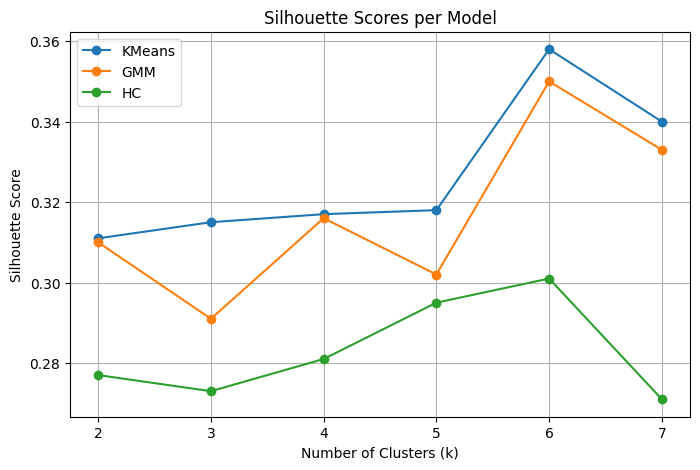

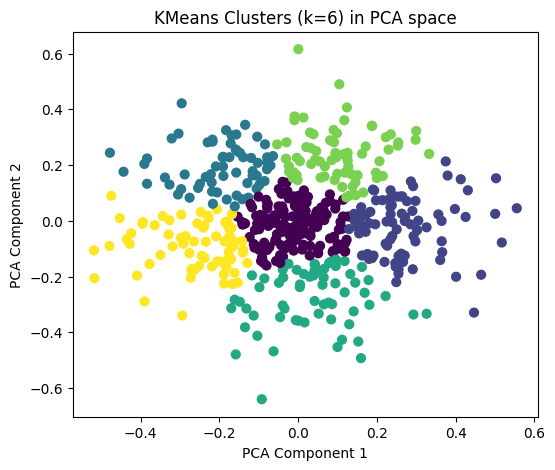

In [ ]:
plt.figure(figsize=(8, 5))
for model, model_scores in scores.items():
    plt.plot(list(model_scores.keys()), list(model_scores.values()), marker='o', label=model)
plt.title("Silhouette Scores per Model")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(True)
plt.show()

# --- Visualization 2: Clusters in PCA space ---
if best_model == "KMeans":
    final_model = KMeans(n_clusters=best_k, random_state=42, n_init=5, max_iter=200)
elif best_model == "GMM":
    final_model = GaussianMixture(n_components=best_k, random_state=42, n_init=2, max_iter=200)
else:
    final_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')

labels = final_model.fit_predict(pca_data)

plt.figure(figsize=(6, 5))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels, cmap='viridis', s=40)
plt.title(f"{best_model} Clusters (k={best_k}) in PCA space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-04.csv')
df.head(5)


,V1,V2,V3,V4,V5
0,0.214030,0.100057,-0.887758,-0.280269,0.038000
1,-0.522185,0.974283,0.558264,-0.614753,0.013866
2,0.230652,0.988988,0.016620,-0.224827,0.074689
3,0.140561,-0.111543,0.469752,0.973430,-0.190863
4,-0.741952,0.410469,-0.975351,-0.653820,-0.060877


In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

Silhouette Scores per Epsilon:
eps=0.05 -> score=0.002
eps=0.10 -> score=0.328
eps=0.15 -> score=0.321

3. Best epsilon: 0.10
   Best silhouette score: 0.328
4. Number of outliers detected: 7


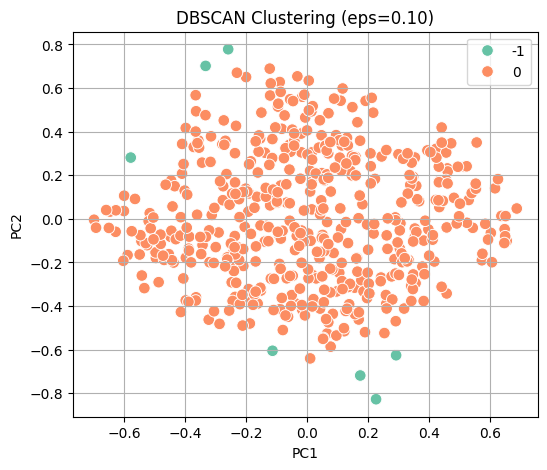

In [ ]:
eps_values = np.arange(0.05, 1.0, 0.05)
silhouette_scores = {}

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=4)  # Best practice: min_samples=4 for 2D data
    labels = dbscan.fit_predict(pca_data)

    # Only evaluate if there are >1 clusters (excluding noise)
    unique_labels = set(labels)
    if len(unique_labels) > 1 and -1 in labels:
        score = silhouette_score(pca_data, labels)
        silhouette_scores[eps] = score

# Display results
print("Silhouette Scores per Epsilon:")
for eps, score in silhouette_scores.items():
    print(f"eps={eps:.2f} -> score={score:.3f}")

best_eps = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n3. Best epsilon: {best_eps:.2f}")
print(f"   Best silhouette score: {silhouette_scores[best_eps]:.3f}")

# Fit final DBSCAN with best epsilon
best_dbscan = DBSCAN(eps=best_eps, min_samples=4)
labels = best_dbscan.fit_predict(pca_data)

# Count outliers
outliers = np.sum(labels == -1)
print(f"4. Number of outliers detected: {outliers}")

# Visualize DBSCAN Clusters
plt.figure(figsize=(6,5))
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=labels, palette="Set2", s=70)
plt.title(f"DBSCAN Clustering (eps={best_eps:.2f})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-02.csv')
data.head(5)


,V1,V2,V3,V4,V5
0,4.546780,19.484946,-0.976759,-1.399805,0.642537
1,4.028151,19.709271,-0.855106,-0.701296,0.787845
2,5.280579,20.175870,-0.215013,0.949428,0.550183
3,3.289170,18.632377,-0.040122,-0.095927,1.215803
4,5.336267,20.578907,0.200041,-0.496447,-1.575399


In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Apply PCA with 2 components
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled_data)

# Convert to DataFrame for easier handling
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

In [ ]:
# Test different clustering algorithms and cluster numbers
n_clusters_range = range(2, 8)
models = {
    'KMeans': KMeans(random_state=42),
    'Hierarchical': AgglomerativeClustering(linkage='ward'),
    'GMM': GaussianMixture(random_state=42)
}

best_score = -1
best_model = None
best_n_clusters = None
all_results = []

print("Clustering Performance Comparison:")
print("=" * 60)

for model_name, model in models.items():
    print(f"\n{model_name}:")
    print("-" * 30)

    for n_clusters in n_clusters_range:
        if model_name == 'GMM':
            # GMM uses fit_predict differently
            gmm = GaussianMixture(n_components=n_clusters, random_state=42)
            labels = gmm.fit_predict(pca_df)
            score = silhouette_score(pca_df, labels)
        else:
            if model_name == 'KMeans':
                model.set_params(n_clusters=n_clusters)
            else:  # Hierarchical
                model.set_params(n_clusters=n_clusters)
            labels = model.fit_predict(pca_df)
            score = silhouette_score(pca_df, labels)

        all_results.append({
            'model': model_name,
            'n_clusters': n_clusters,
            'silhouette_score': score
        })

        print(f"  Clusters: {n_clusters}, Silhouette Score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_model = model_name
            best_n_clusters = n_clusters

# Display final results
print("\n" + "=" * 60)
print("FINAL RESULTS:")
print("=" * 60)
print(f"Best Model: {best_model}")
print(f"Best Number of Clusters: {best_n_clusters}")
print(f"Best Silhouette Score: {best_score:.4f}")


Clustering Performance Comparison:

KMeans:
------------------------------
  Clusters: 2, Silhouette Score: 0.3524
  Clusters: 3, Silhouette Score: 0.3789
  Clusters: 4, Silhouette Score: 0.3670
  Clusters: 5, Silhouette Score: 0.3171
  Clusters: 6, Silhouette Score: 0.3589
  Clusters: 7, Silhouette Score: 0.3481

Hierarchical:
------------------------------
  Clusters: 2, Silhouette Score: 0.3063
  Clusters: 3, Silhouette Score: 0.3245
  Clusters: 4, Silhouette Score: 0.3322
  Clusters: 5, Silhouette Score: 0.2917
  Clusters: 6, Silhouette Score: 0.3086
  Clusters: 7, Silhouette Score: 0.2976

GMM:
------------------------------
  Clusters: 2, Silhouette Score: 0.3516
  Clusters: 3, Silhouette Score: 0.3737
  Clusters: 4, Silhouette Score: 0.3589
  Clusters: 5, Silhouette Score: 0.2737
  Clusters: 6, Silhouette Score: 0.3510
  Clusters: 7, Silhouette Score: 0.3268

FINAL RESULTS:
Best Model: KMeans
Best Number of Clusters: 3
Best Silhouette Score: 0.3789


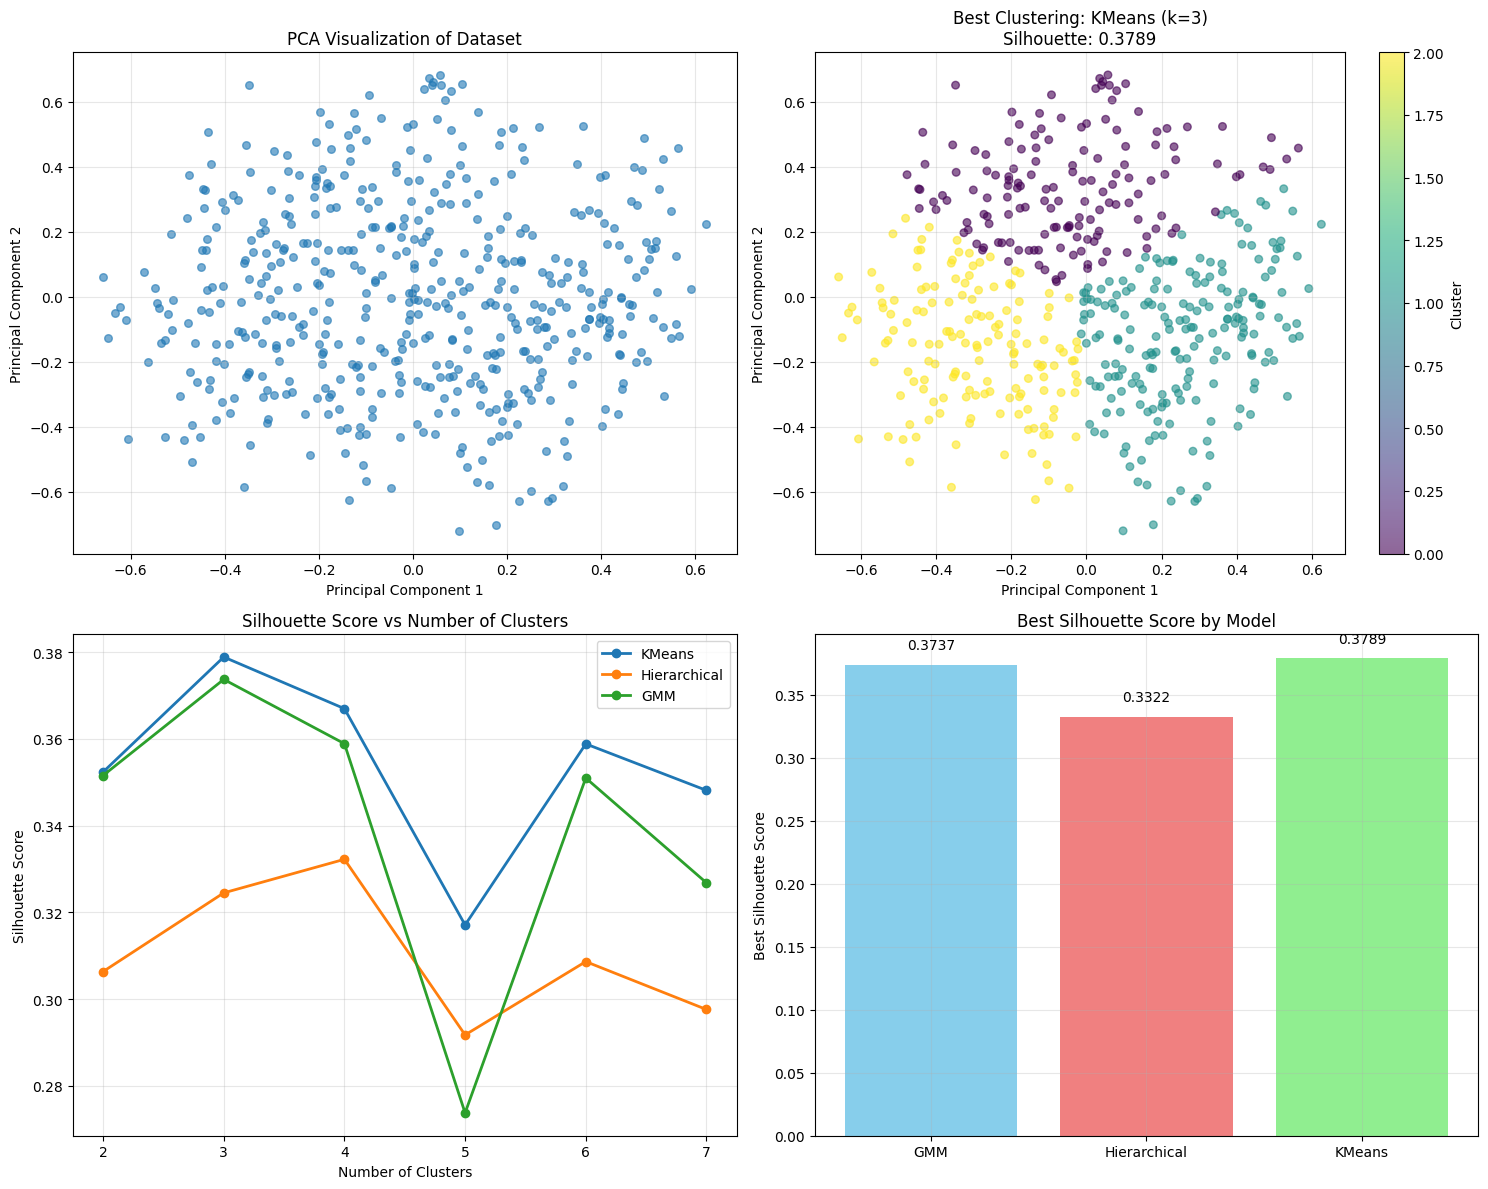


Detailed Comparison Table:
model          GMM  Hierarchical  KMeans
n_clusters                              
2           0.3516        0.3063  0.3524
3           0.3737        0.3245  0.3789
4           0.3589        0.3322  0.3670
5           0.2737        0.2917  0.3171
6           0.3510        0.3086  0.3589
7           0.3268        0.2976  0.3481


In [ ]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: PCA visualization
axes[0, 0].scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6, s=30)
axes[0, 0].set_xlabel('Principal Component 1')
axes[0, 0].set_ylabel('Principal Component 2')
axes[0, 0].set_title('PCA Visualization of Dataset')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Best clustering result
if best_model == 'KMeans':
    best_cluster = KMeans(n_clusters=best_n_clusters, random_state=42)
elif best_model == 'Hierarchical':
    best_cluster = AgglomerativeClustering(n_clusters=best_n_clusters, linkage='ward')
else:  # GMM
    best_cluster = GaussianMixture(n_components=best_n_clusters, random_state=42)

if best_model == 'GMM':
    labels = best_cluster.fit_predict(pca_df)
else:
    labels = best_cluster.fit_predict(pca_df)

scatter = axes[0, 1].scatter(pca_df['PC1'], pca_df['PC2'], c=labels,
                            cmap='viridis', alpha=0.6, s=30)
axes[0, 1].set_xlabel('Principal Component 1')
axes[0, 1].set_ylabel('Principal Component 2')
axes[0, 1].set_title(f'Best Clustering: {best_model} (k={best_n_clusters})\nSilhouette: {best_score:.4f}')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 1], label='Cluster')

# Plot 3: Silhouette scores by model and cluster number
results_df = pd.DataFrame(all_results)
for model in models.keys():
    model_data = results_df[results_df['model'] == model]
    axes[1, 0].plot(model_data['n_clusters'], model_data['silhouette_score'],
                   marker='o', label=model, linewidth=2)

axes[1, 0].set_xlabel('Number of Clusters')
axes[1, 0].set_ylabel('Silhouette Score')
axes[1, 0].set_title('Silhouette Score vs Number of Clusters')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Best scores by model
best_scores = results_df.groupby('model')['silhouette_score'].max()
models_list = list(best_scores.index)
scores_list = list(best_scores.values)

bars = axes[1, 1].bar(models_list, scores_list, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1, 1].set_ylabel('Best Silhouette Score')
axes[1, 1].set_title('Best Silhouette Score by Model')
axes[1, 1].grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, scores_list):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Display detailed comparison table
print("\nDetailed Comparison Table:")
print("=" * 50)
comparison_df = results_df.pivot(index='n_clusters', columns='model', values='silhouette_score')
print(comparison_df.round(4))

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-05.csv')
data.head(5)


,V1,V2,V4,V5,V6
0,-0.158353,-0.362053,-0.105631,-0.668469,0.439701
1,-0.049653,0.406525,-0.977228,0.399257,0.121315
2,0.403011,-0.099121,0.206530,-0.745633,-0.883326
3,-0.177414,-0.995773,-0.955961,0.392940,0.800324
4,0.664575,0.810209,-0.126706,0.952770,0.739398


In [ ]:
# Apply MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Apply PCA with 2 components
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled_data)

# Convert to DataFrame for easier handling
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

In [ ]:
min_samples = 4
eps_values = np.arange(0.1, 1.0, 0.05)
best_eps = None
best_score = -1
outliers_count = None
best_labels = None

silhouette_scores = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(pca_df)

    # Calculate silhouette score (excluding outliers labeled as -1)
    unique_labels = np.unique(labels)
    if len(unique_labels) > 1:  # Need at least 2 clusters (including noise)
        # Filter out noise points for silhouette score calculation
        mask = labels != -1
        if len(np.unique(labels[mask])) > 1:  # Need at least 2 real clusters
            score = silhouette_score(pca_df[mask], labels[mask])
            silhouette_scores.append(score)

            if score > best_score:
                best_score = score
                best_eps = eps
                outliers_count = np.sum(labels == -1)
                best_labels = labels
        else:
            silhouette_scores.append(-1)
    else:
        silhouette_scores.append(-1)

print(f"Best epsilon value: {best_eps:.2f}")
print(f"Best silhouette score: {best_score:.4f}")
print(f"Number of outliers detected: {outliers_count}")

Best epsilon value: 0.10
Best silhouette score: 0.3224
Number of outliers detected: 18


In [ ]:
final_dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
final_labels = final_dbscan.fit_predict(pca_df)

# Count clusters (excluding noise)
n_clusters = len(set(final_labels)) - (1 if -1 in final_labels else 0)
print(f"Number of clusters found: {n_clusters}")

Number of clusters found: 2


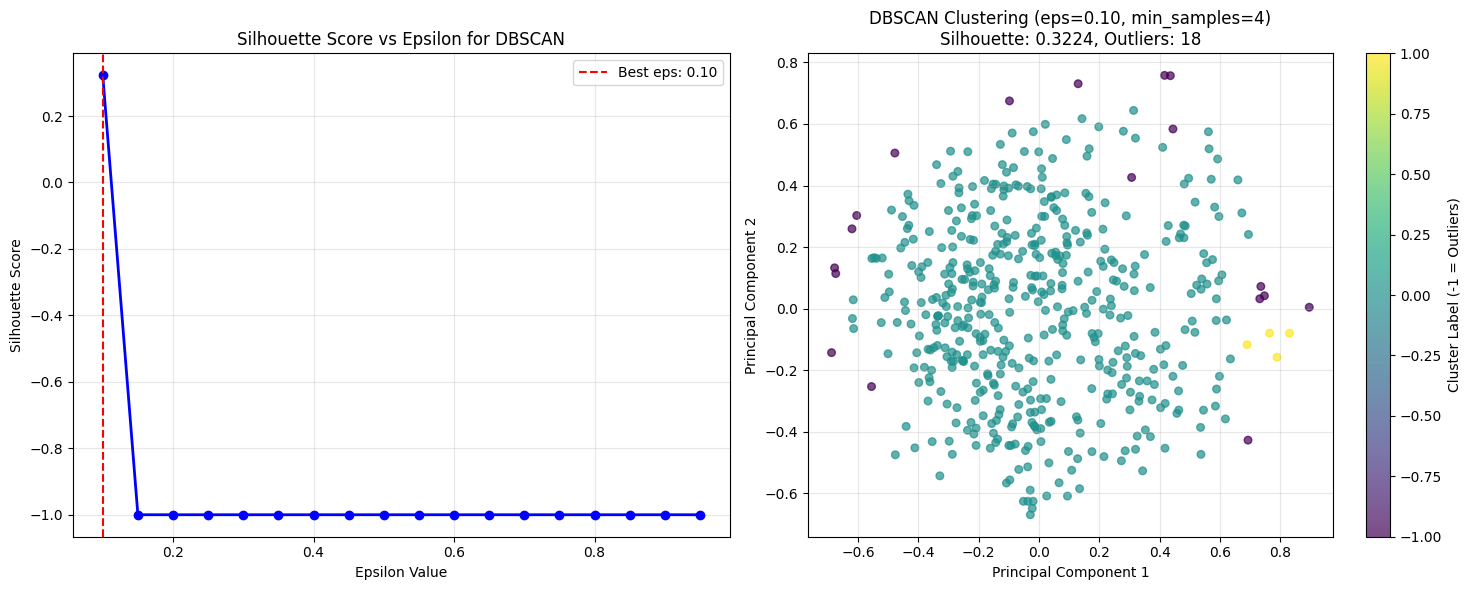


Cluster Distribution:
Outliers (label -1): 18 points
Cluster 0: 478 points
Cluster 1: 4 points

PCA Explained Variance:
PC1: 0.2617 (26.17%)
PC2: 0.2330 (23.30%)
Total: 0.4947 (49.47%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Silhouette scores vs epsilon
axes[0].plot(eps_values, silhouette_scores, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Epsilon Value')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs Epsilon for DBSCAN')
axes[0].axvline(x=best_eps, color='r', linestyle='--', label=f'Best eps: {best_eps:.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: DBSCAN clustering results
scatter = axes[1].scatter(pca_df['PC1'], pca_df['PC2'], c=best_labels,
                         cmap='viridis', alpha=0.7, s=30)
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].set_title(f'DBSCAN Clustering (eps={best_eps:.2f}, min_samples={min_samples})\n'
                 f'Silhouette: {best_score:.4f}, Outliers: {outliers_count}')
axes[1].grid(True, alpha=0.3)

# Create a separate colorbar for outliers
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Cluster Label (-1 = Outliers)')

plt.tight_layout()
plt.show()

# Display detailed information about clusters
unique_labels = np.unique(best_labels)
print(f"\nCluster Distribution:")
print("=" * 30)
for label in unique_labels:
    if label == -1:
        print(f"Outliers (label -1): {np.sum(best_labels == label)} points")
    else:
        print(f"Cluster {label}: {np.sum(best_labels == label)} points")

# Print variance explained by PCA components
print(f"\nPCA Explained Variance:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Total: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-03.csv')
data.head(5)


,V1,V2,V3,V4,V5
0,-8.536251,10.944791,6.811667,-5.059278,-3.186717
1,-11.222700,11.844886,5.491410,-5.308275,-4.855787
2,-10.917374,8.133306,6.445988,-5.033128,-8.411694
3,-13.920717,9.838101,7.073802,-6.943141,-5.553332
4,-4.238046,6.763134,4.887413,0.689276,-6.939081


In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled)

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

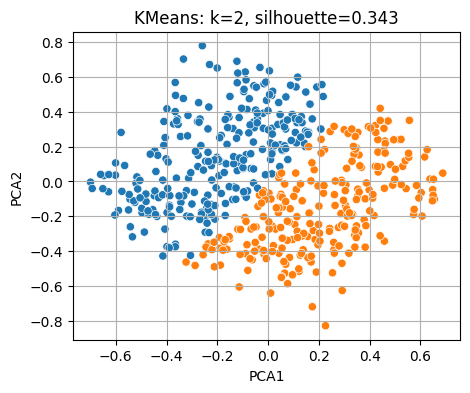

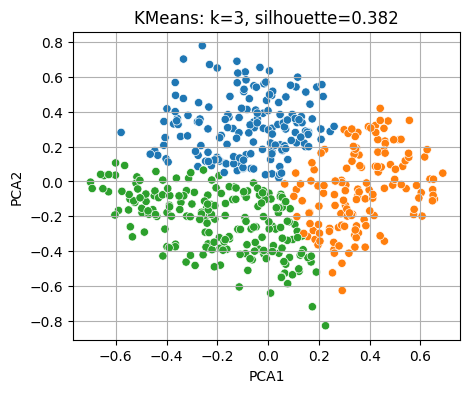

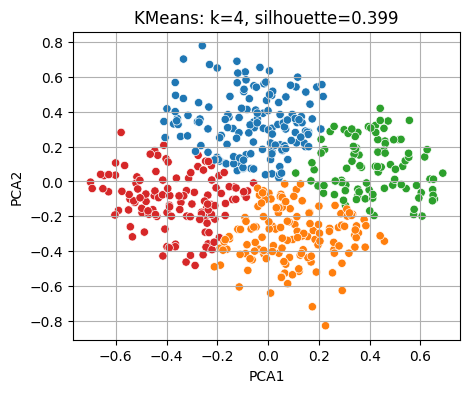

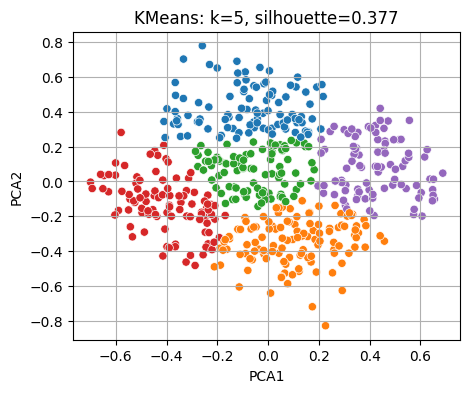

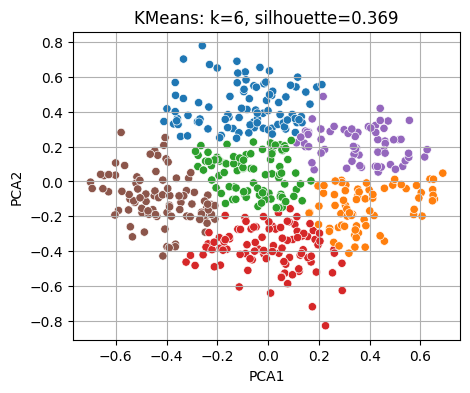

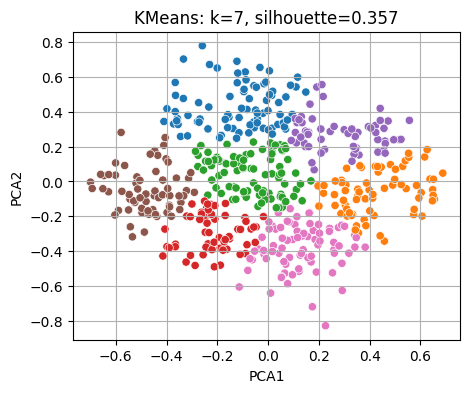

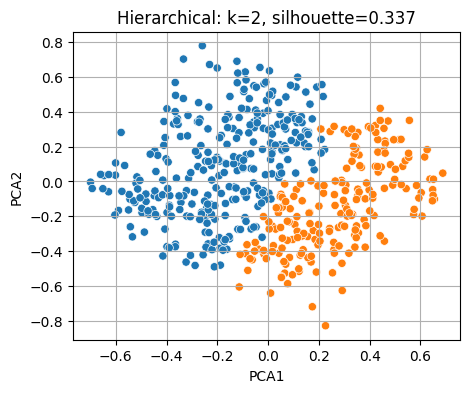

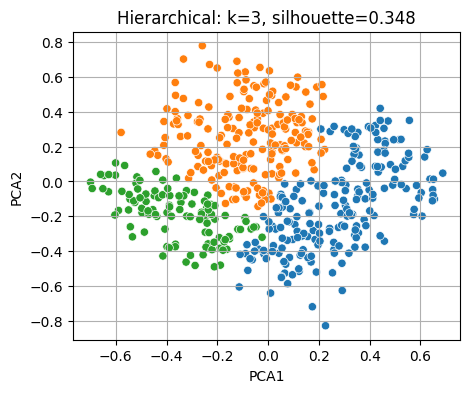

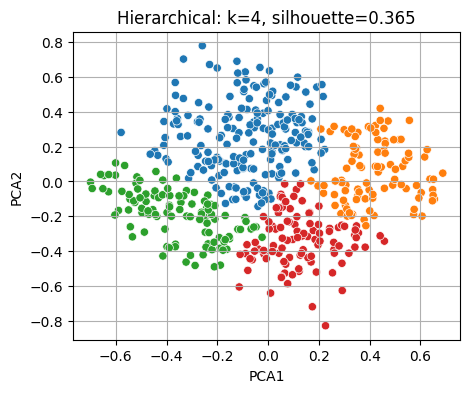

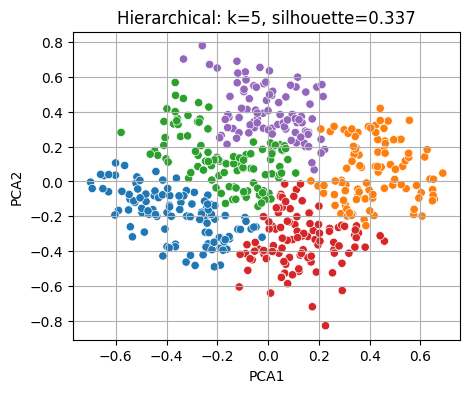

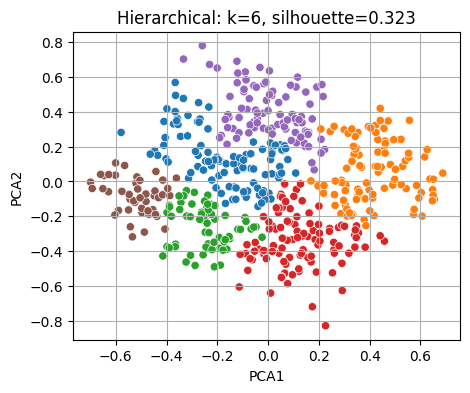

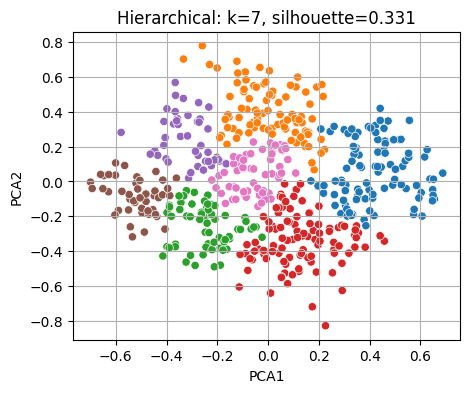

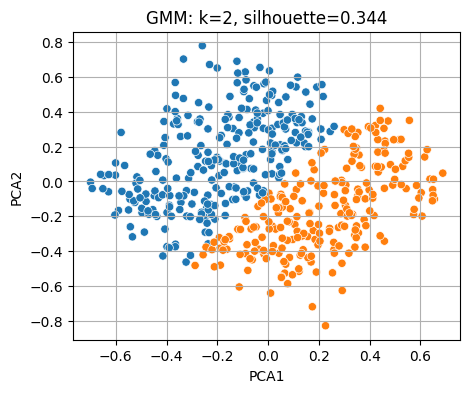

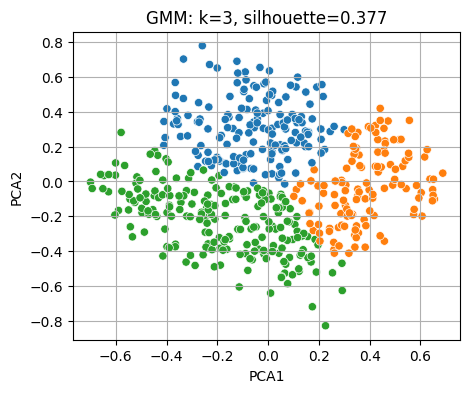

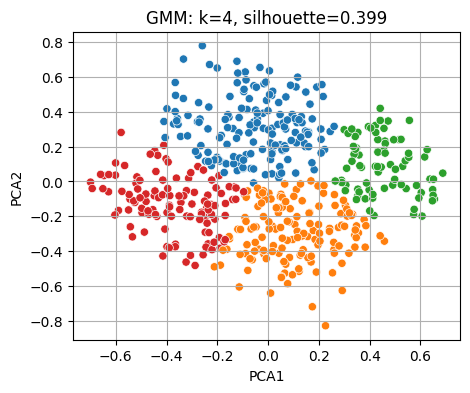

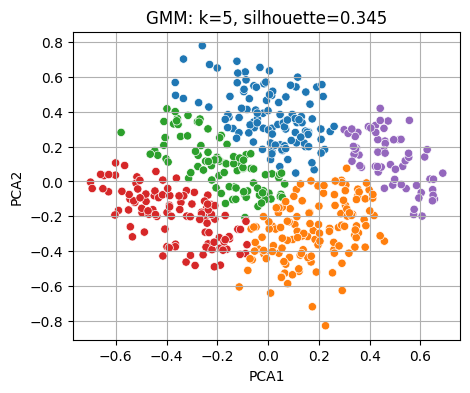

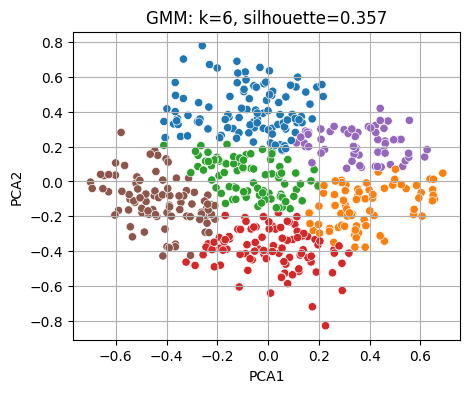

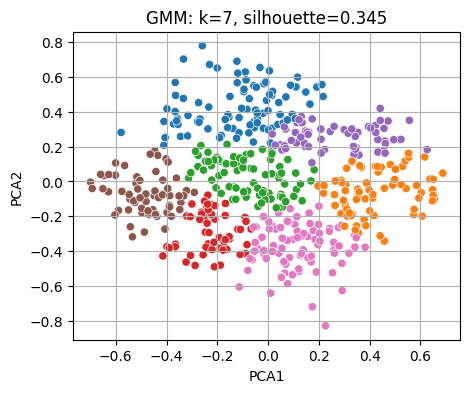

In [ ]:
# Define range of clusters to test
cluster_range = range(2, 8)
results = []

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(pca_data)
    sil = silhouette_score(pca_data, labels)
    results.append(('KMeans', k, sil))
    # plot
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=labels, palette='tab10', legend=None)
    plt.title(f'KMeans: k={k}, silhouette={sil:.3f}')
    plt.xlabel('PCA1'); plt.ylabel('PCA2'); plt.grid(True)
    plt.show()

   # 7. Hierarchical (AgglomerativeClustering with ‘ward’)
for k in cluster_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(pca_data)
    sil = silhouette_score(pca_data, labels)
    results.append(('Hierarchical', k, sil))
    # plot
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=labels, palette='tab10', legend=None)
    plt.title(f'Hierarchical: k={k}, silhouette={sil:.3f}')
    plt.xlabel('PCA1'); plt.ylabel('PCA2'); plt.grid(True)
    plt.show()

    # 8. GMM
for k in cluster_range:
    model = GaussianMixture(n_components=k, random_state=42)
    labels = model.fit_predict(pca_data)
    sil = silhouette_score(pca_data, labels)
    results.append(('GMM', k, sil))
    # plot
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=labels, palette='tab10', legend=None)
    plt.title(f'GMM: k={k}, silhouette={sil:.3f}')
    plt.xlabel('PCA1'); plt.ylabel('PCA2'); plt.grid(True)
    plt.show()

In [ ]:
results_df = pd.DataFrame(results, columns=['Model','k','Silhouette'])
print(results_df.sort_values(by='Silhouette', ascending=False))

           Model  k  Silhouette
14           GMM  4    0.399276
2         KMeans  4    0.398520
1         KMeans  3    0.381711
3         KMeans  5    0.377489
13           GMM  3    0.377016
4         KMeans  6    0.369057
8   Hierarchical  4    0.364721
16           GMM  6    0.357287
5         KMeans  7    0.356616
7   Hierarchical  3    0.348429
15           GMM  5    0.344973
17           GMM  7    0.344530
12           GMM  2    0.344274
0         KMeans  2    0.343411
6   Hierarchical  2    0.337453
9   Hierarchical  5    0.336618
11  Hierarchical  7    0.331024
10  Hierarchical  6    0.323206


In [ ]:
# 10. Pick best
best = results_df.loc[results_df['Silhouette'].idxmax()]
print(f"Best model = {best['Model']} with k = {best['k']} (silhouette = {best['Silhouette']:.3f})")

Best model = GMM with k = 4 (silhouette = 0.399)
